In [62]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [63]:
with open('../data/results/evolution_history_gaußian.json', 'r') as f:
    history = json.load(f)
    f.close()

print(f"Solution {history['best_overall']} found in generation {history['generations_taken_for_optimal']}")

Solution exp((x0 / (-3.09e+00 / x0))) found in generation 445


In [64]:
generations = [int(g) for g in list(history['species'].keys())]
generations.sort()
generations = np.array(generations)
print(f"Generations: {generations}")

Generations: [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175
 180 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265
 270 275 280 285 290 295 300 305 310 315 320 325 330 335 340 345 350 355
 360 365 370 375 380 385 390 395 400 405 410 415 420 425 430 435 440 445
 450 455 460 465 470 475 480 485 490 495]


In [65]:
print("Hall of Fame:")
for key in sorted([int(k) for k in history['hall_of_fame'].keys()]):
	print(f"Generation {key}: {history['hall_of_fame'][str(key)]}")

Hall of Fame:
Generation 0: 2.47e-01
Generation 1: sin((-9.59e+00 min x0))
Generation 2: 1.66e-01
Generation 3: (7.83e-01 min (4.13e-02 / (x0 * x0)))
Generation 6: sin((sin((8.93e+00 min x0)) / x0))
Generation 9: (7.83e-01 min (7.83e-01 / (x0 * x0)))
Generation 38: (7.83e-01 min (1.00e+00 / (x0 * x0)))
Generation 50: (1.00e+00 min (1.00e+00 / (x0 * x0)))
Generation 108: sin((7.83e+00 + atan((x0 * x0))))
Generation 132: sin((7.84e+00 + atan((x0 * x0))))
Generation 135: sin((7.83e+00 - atan((x0 * x0))))
Generation 136: cos(atan((x0 * x0)))
Generation 445: exp((x0 / (-3.09e+00 / x0)))


In [66]:
history['species']['0'][0]

{'id': 2,
 'size': 88,
 'representative': '-1.02e+01',
 'loss_raws': [1,
  1.0515906733547578,
  1.1220915368593745,
  1.1737865338907691,
  1.1817799457294567,
  1.2203165484177338,
  1.281178016590862,
  1.6630741620211256,
  3.012174616201088,
  3.032383994975349,
  4.399017338530871,
  5.021377851324394,
  5.1824214422954125,
  5.193899475389832,
  6.040143042844922,
  6.088061034968542,
  6.241211606096704,
  6.612813659158134,
  7.111288047872658,
  7.227010733097558,
  7.26218030119948,
  7.850985038439609,
  12.619745127342485,
  13.84179752207308,
  14.028918450154757,
  14.44501699579658,
  15.29692765944672,
  17.134916773097018,
  18.348641391307858,
  20.74431274132657,
  20.83806928772364,
  21.5336311594448,
  25.145248402683027,
  25.564311285842688,
  25.82454835171745,
  26.396788796215006,
  26.85128264868843,
  29.79797533751226,
  33.03778459535439,
  35.880766994346516,
  36.315433249969175,
  40.94773618081353,
  45.315634663278765,
  51.42484823480675,
  51.8470

In [67]:
species_id_to_idx = {}
idx_to_species_id = {}
idx_to_expression = {}
idx = 0
for gen in generations:
	for species in history['species'][str(gen)]:
		if species['id'] not in species_id_to_idx:
			species_id_to_idx[species['id']] = idx
			idx_to_species_id[idx] = species['id']
			idx += 1
		idx_to_expression[species_id_to_idx[species['id']]] = species['representative']
print(f"Unique species count: {len(species_id_to_idx)}")

Unique species count: 348


In [68]:
species_sizes_over_time = np.zeros((len(generations), len(species_id_to_idx)), dtype=int)
species_loss_over_time = np.zeros((len(generations), len(species_id_to_idx), 3), dtype=float)*np.nan
species_expressions_over_time = np.full((len(generations), len(species_id_to_idx)), fill_value='', dtype=object)
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		species_sizes_over_time[gi, species_idx] = species['size']
		species_loss_over_time[gi, species_idx, 0] = np.min(species['loss_finals'])
		species_loss_over_time[gi, species_idx, 1] = np.mean(species['loss_finals'])
		species_loss_over_time[gi, species_idx, 2] = np.max(species['loss_finals'])
		species_expressions_over_time[gi, species_idx] = species['representative']

In [69]:
sorter = np.argsort(species_loss_over_time[-1,:,0]) #np.argsort(np.sum(species_sizes_over_time, axis=0))
for idx in sorter[:5]:
	id = idx_to_species_id[idx]
	expr = idx_to_expression[idx]
	size = species_sizes_over_time[-1][idx]
	fitness = species_loss_over_time[-1,idx,0]
	print(f"Species {id} of size {size} with loss {fitness:0.4e} expression: {expr}")
sorted_ids = np.array([idx_to_species_id[idx] for idx in sorter])
sorted_exprs = species_expressions_over_time[:, sorter]
sorted_sizes = species_sizes_over_time[:, sorter]
sorted_fitness = species_loss_over_time[:, sorter, :]
cmap = plt.get_cmap('prism')
cols = np.array([cmap((i%50) / 50) for i in sorted_ids])

Species 3 of size 41 with loss 3.0462e-02 expression: exp((x0 / (-3.09e+00 / x0)))
Species 0 of size 47 with loss 3.6695e-02 expression: cos(atan((x0 * x0)))
Species 20 of size 15 with loss 1.1454e-01 expression: abs(cos(atan((x0 * (x0 * asin(atan(atan(x0))))))))
Species 4 of size 21 with loss 1.1543e-01 expression: exp(((-3.09e+00 mod (x0 * x0)) min (5.52e-01 - x0)))
Species 156 of size 9 with loss 2.3937e-01 expression: abs(cos(atan(log(exp((x0 / -3.20e-01))))))


In [70]:
""" fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,6))
ax1.stackplot(generations, sorted_sizes[:,::-1].T, colors=cols[::-1], baseline='zero')
ax1.set(xlim=(generations[0], generations[-1]), ylim=(0, np.sum(species_sizes_over_time[0])))
ax1.set_xlabel('Generation')
ax1.set_ylabel('Species Size')
ax1.set_title('Species Size Over Generations')


X = generations
Y = sorted_fitness[:,:,0]
lw = (sorted_sizes/np.max(sorted_sizes[-1]))**2 * 6
for i in range(Y.shape[1]):
	idxs = np.where(~np.isnan(Y[:,i]))[0]
	points = np.column_stack([X[idxs], Y[idxs,i]]).reshape(-1, 1, 2)
	segments = np.concatenate([points[:-1], points[1:]], axis=1)
	lc = LineCollection(segments, linewidths=lw[idxs,i][1:], colors=cols[i])
	ax2.add_collection(lc)
ax2.set_xlim(1, np.max(X))
ax2.set_ylim(np.nanmin(Y)*9e-1, np.nanmin(Y)*3e2)
ax2.set_yscale('log')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Generation')
ax2.set_ylabel('Best Loss')
ax2.set_title('Performance of Species Over Generations')

plt.show() """

" fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,6))\nax1.stackplot(generations, sorted_sizes[:,::-1].T, colors=cols[::-1], baseline='zero')\nax1.set(xlim=(generations[0], generations[-1]), ylim=(0, np.sum(species_sizes_over_time[0])))\nax1.set_xlabel('Generation')\nax1.set_ylabel('Species Size')\nax1.set_title('Species Size Over Generations')\n\n\nX = generations\nY = sorted_fitness[:,:,0]\nlw = (sorted_sizes/np.max(sorted_sizes[-1]))**2 * 6\nfor i in range(Y.shape[1]):\n\tidxs = np.where(~np.isnan(Y[:,i]))[0]\n\tpoints = np.column_stack([X[idxs], Y[idxs,i]]).reshape(-1, 1, 2)\n\tsegments = np.concatenate([points[:-1], points[1:]], axis=1)\n\tlc = LineCollection(segments, linewidths=lw[idxs,i][1:], colors=cols[i])\n\tax2.add_collection(lc)\nax2.set_xlim(1, np.max(X))\nax2.set_ylim(np.nanmin(Y)*9e-1, np.nanmin(Y)*3e2)\nax2.set_yscale('log')\nax2.set_xscale('log')\nax2.grid(True, alpha=0.3)\nax2.set_xlabel('Generation')\nax2.set_ylabel('Best Loss')\nax2.set_title('Performance of Species

In [71]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Species Size Over Generations', 'Performance of Species Over Generations'),
                    horizontal_spacing=0.05)

# --- Left subplot: Stacked area chart (manual stacking) ---
# Reverse order to match matplotlib stackplot stacking order
stacked = np.cumsum(sorted_sizes[:, ::-1], axis=1)
rev_cols = cols[::-1]

for i in range(stacked.shape[1]):
    rgba = tuple((rev_cols[i] * 255).astype(int))
    color = f'rgba({rgba[0]},{rgba[1]},{rgba[2]},1.0)'
    fig.add_trace(
        go.Scatter(
            x=generations,
            y=stacked[:, i],
            mode='lines',
            line=dict(width=0.0, color=color),
            fillcolor=color,
            fill='tonexty' if i > 0 else 'tozeroy',
            name=f'{sorted_ids[-(i+1)]}',
            text=sorted_exprs[:, -(i+1)],
            hovertemplate='ID: %{fullData.name}<br>Generation: %{x}<br>Size: %{y}<br>Expression: %{text}',
            legendgroup=f'g{i}',
            showlegend=False,
        ),
        row=1, col=1
    )

fig.update_xaxes(title_text='Generation', row=1, col=1,
                 range=[generations[0], generations[-1]])
fig.update_yaxes(title_text='Species Size', row=1, col=1,
                 range=[0, float(stacked[-1, -1])])

# --- Right subplot: Performance lines with variable segment width ---
X = generations
Y = sorted_fitness[:, :, 0]
lw_vals = (sorted_sizes / np.max(sorted_sizes[-1]))**2 * 6

for i in range(Y.shape[1]):
    idxs = np.where(~np.isnan(Y[:, i]))[0]
    if len(idxs) < 2:
        continue
    rgba = tuple((cols[i] * 255).astype(int))
    color = f'rgba({rgba[0]},{rgba[1]},{rgba[2]},1.0)'
    for j in range(len(idxs) - 1):
        fig.add_trace(
            go.Scatter(
                x=[X[idxs[j]], X[idxs[j+1]]],
                y=[Y[idxs[j], i], Y[idxs[j+1], i]],
                mode='lines',
                line=dict(width=max(lw_vals[idxs[j+1], i], 0.5), color=color),
                name=f'{sorted_ids[i]}',
                text=str(sorted_exprs[idxs[j], i]),
                hovertemplate='ID: %{fullData.name}<br>Generation: %{x}<br>Loss: %{y}<br>Expression: %{fullData.text}',
                legendgroup=f'g{i}',
                showlegend=False,
                hoverinfo='skip',
            ),
            row=1, col=2
        )

fig.update_xaxes(title_text='Generation', type='log', row=1, col=2,
                 range=[0, np.log10(float(np.max(X)))])
ymin = float(np.nanmin(Y))
fig.update_yaxes(title_text='Best Loss', type='log', row=1, col=2,
                 range=[np.log10(ymin * 9e-1), np.log10(ymin * 3e2)])

fig.update_layout(
    height=600, width=1200,
    showlegend=False,
    plot_bgcolor='white',
    title='Species Evolution',
)

fig.show()

In [72]:
data_over_time = np.ones((4, 3, len(generations), len(species_id_to_idx)))*np.nan
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		for idx, name in {0:'loss_raws',1:'complexities',2:'loss_insts',3:'loss_finals'}.items():
			for jdx,fnc in {0:np.min,1:np.median,2:np.max}.items():
				arr = np.array(species[name]).astype(float)
				if np.isnan(arr).any():
					print(f"NaN found in {name} for species {species['id']} in generation {gen}")
				if np.isinf(arr).any():
					print(f"Inf found in {name} for species {species['id']} in generation {gen}")
				y = np.array(fnc([species[name]])).astype(float)
				if np.isnan(y):
					print(f"NaN found after aggregation in {name} for species {species['id']} in generation {gen}")
				elif np.isinf(y):
					print(f"Inf found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
				elif y > 1e6:
					#print(f"Unrealistically high value {y} found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
					data_over_time[idx, jdx, gi, species_idx] = np.nan
				else:
					data_over_time[idx, jdx, gi, species_idx] = y

Inf found after aggregation using median in loss_raws for species 1 in generation 0
Inf found after aggregation using median in loss_finals for species 1 in generation 0
Inf found after aggregation using median in loss_raws for species 15 in generation 5
Inf found after aggregation using median in loss_insts for species 15 in generation 5
Inf found after aggregation using median in loss_finals for species 15 in generation 5
Inf found after aggregation using median in loss_raws for species 13 in generation 5
Inf found after aggregation using median in loss_finals for species 13 in generation 5
Inf found after aggregation using median in loss_raws for species 30 in generation 10
Inf found after aggregation using median in loss_finals for species 30 in generation 10
Inf found after aggregation using median in loss_raws for species 102 in generation 55
Inf found after aggregation using median in loss_finals for species 102 in generation 55
Inf found after aggregation using median in loss_r

/tmp/ipykernel_14152/2764759316.py:1: RuntimeWarning:

All-NaN slice encountered



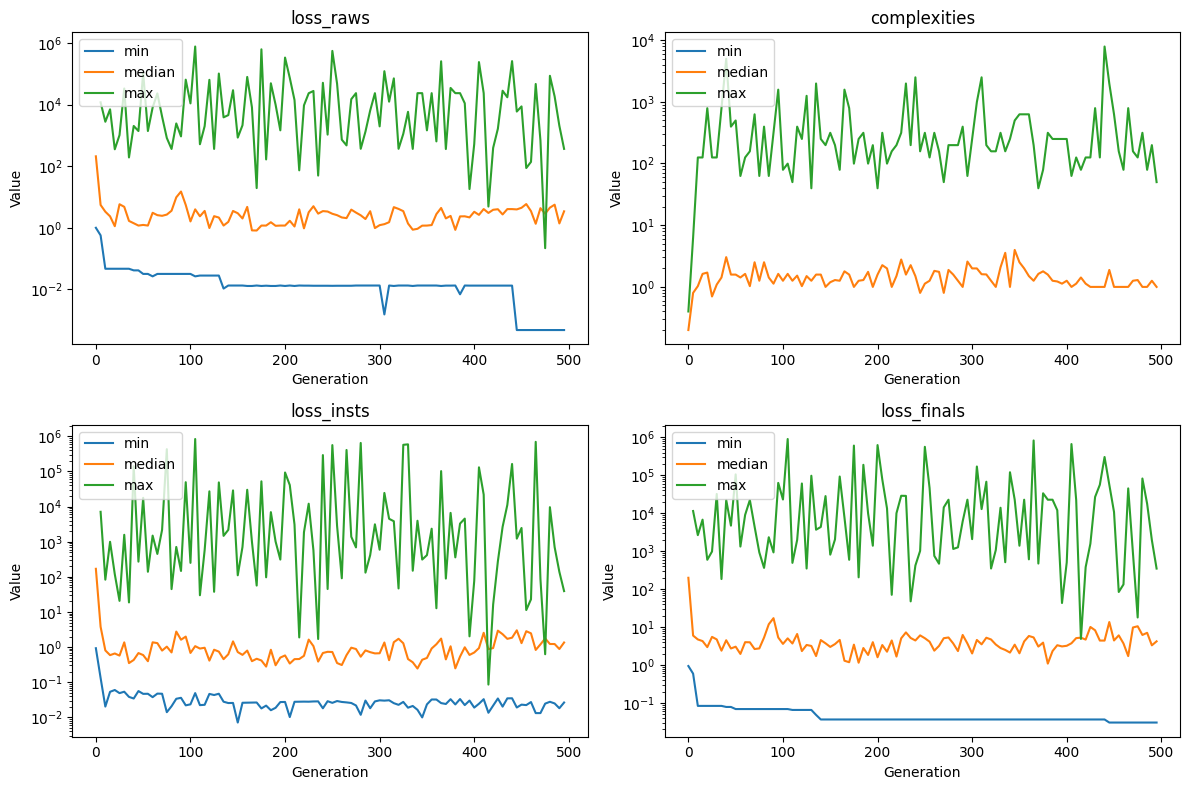

In [73]:
average_data_over_time = np.array([np.nanmin(data_over_time[:,0], axis=2), np.nanmedian(data_over_time[:,1], axis=2), np.nanmax(data_over_time[:,2], axis=2)])
average_data_over_time = np.transpose(average_data_over_time, (1, 0,2))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
metric_names = ['loss_raws', 'complexities', 'loss_insts', 'loss_finals']
for idx in range(4):
	for jdx in range(3) if idx == 1 else range(3):
		ax[idx//2, idx%2].semilogy(generations, average_data_over_time[idx, jdx], label=['min', 'median', 'max'][jdx])
	ax[idx//2, idx%2].set_title(metric_names[idx])
	ax[idx//2, idx%2].set_xlabel('Generation')
	ax[idx//2, idx%2].set_ylabel('Value')
	ax[idx//2, idx%2].legend()
plt.tight_layout()
plt.show()